# TAREA 1: Comparación de los libros "La señora Dalloway" y "Una habitación propia" de Virginia Woolf
## Autor: Alejandra Paola Castillo Gallegos


In [22]:
!pip install nltk wordcloud seaborn -q
!pip install pymupdf -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 71.1 MB/s eta 0:00:00


In [23]:
# Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import fitz

import nltk
import re

from collections import Counter
from nltk.util import ngrams
from nltk.corpus import stopwords
from wordcloud import WordCloud

nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [1]:
from google.colab import files
uploaded = files.upload()

Saving La_senora_Dalloway-Woolf_Virginia.pdf to La_senora_Dalloway-Woolf_Virginia.pdf
Saving VIRGINIA WOLF UN HABITACION PROPIA.pdf to VIRGINIA WOLF UN HABITACION PROPIA.pdf


In [26]:
# Importar PDF
def leer_pdf(nombre_pdf):

    documento = fitz.open(nombre_pdf)

    texto = ""

    for pagina in documento:
        texto += pagina.get_text()

    return texto

texto1 = leer_pdf("VIRGINIA WOLF UN HABITACION PROPIA.pdf")
texto2 = leer_pdf("La_senora_Dalloway-Woolf_Virginia.pdf")

print(texto1[:1000])
print(texto2[:1000])

UNA 
HABITACIÓN 
PROPIA 
Virginia Wolf 
Virginia Woolf                                                                           Una habitación propia 
Virginia Woolf                                                                           Una habitación propia 
Seix Barral Biblioteca Formentor 
Virginia Woolf 
Una habitación propia 
Traducción del inglés por  
Laura Pujol 
Virginia Woolf                                                                           Una habitación propia 
Diseño original de la colección: 
Josep Bagà Associats 
Título original: 
A room of one's own 
The Hogarth Press Ltd., Londres 
Primera edición 
en col. Biblioteca Breve: 1967 
Primera edición 
en col. Biblioteca Formentor: mayo 2001 
Tercera impresión: abril 2003 
Cuarta impresión: febrero 2004 
Quinta impresión: noviembre 2005 
Sexta impresión: enero 2008 
© Quentin Bell y Angelica Garnett, 1929 
Derechos exclusivos de esta edición 
en castellano reservados 
para todo el mundo 
y propiedad de la traducc

In [29]:
# Limpieza de datos
stop_words = set(stopwords.words('spanish'))

def limpiar_texto(texto):

    texto = texto.lower()

    palabras = re.findall(
        r'\b[a-záéíóúñü]+\b',
        texto
    )

    palabras = [
        p for p in palabras
        if p not in stop_words
    ]

    return palabras

tokens1 = limpiar_texto(texto1)
tokens2 = limpiar_texto(texto2)

In [31]:
# Estadística descriptiva
def estadisticas(texto,tokens):

    return {
        "Caracteres":len(texto),
        "Palabras":len(tokens),
        "Vocabulario":len(set(tokens)),
        "Longitud promedio":
        np.mean([len(x) for x in tokens])
    }

stats1 = estadisticas(texto1,tokens1)
stats2 = estadisticas(texto2,tokens2)

df_stats = pd.DataFrame(
    [stats1,stats2],
    index=[
        "Una habitación propia",
        "La señora Dalloway"
    ]
)

df_stats

,Caracteres,Palabras,Vocabulario,Longitud promedio
Una habitación propia,241229,20071,7239,6.659509
La señora Dalloway,217156,19060,5774,6.743704


In [32]:
# Frecuencia de palabras
freq1 = Counter(tokens1)
freq2 = Counter(tokens2)

top1 = pd.DataFrame(
    freq1.most_common(20),
    columns=["Palabra","Frecuencia"]
)

top2 = pd.DataFrame(
    freq2.most_common(20),
    columns=["Palabra","Frecuencia"]
)

top1

,Palabra,Frecuencia
0,mujeres,191
1,si,180
2,mujer,140
3,habitación,109
4,propia,104
5,ser,90
6,virginia,82
7,hombres,82
8,woolf,81
9,mente,78


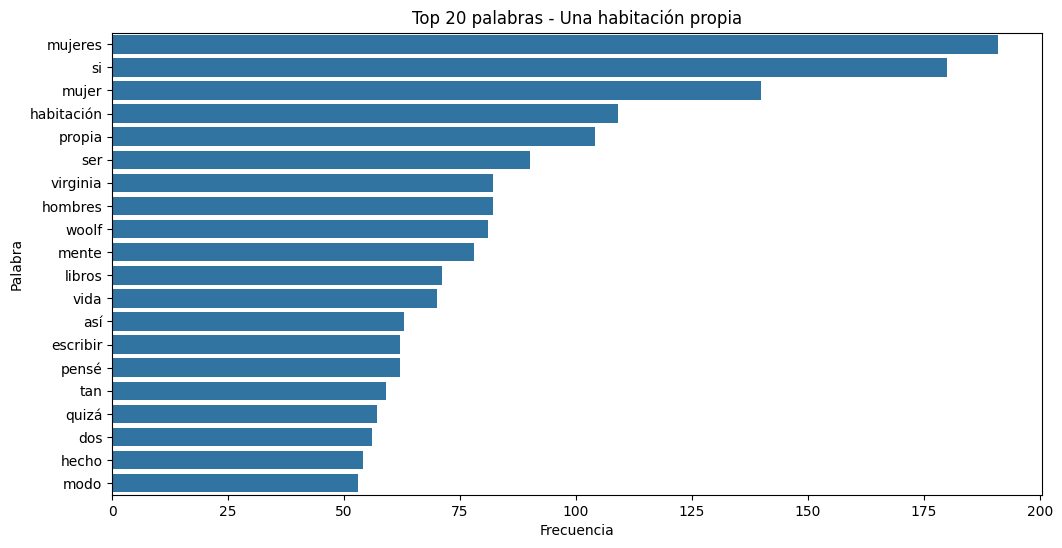

In [33]:
# Gráfica top 20 palabras
plt.figure(figsize=(12,6))

sns.barplot(
    data=top1,
    x="Frecuencia",
    y="Palabra"
)

plt.title(
    "Top 20 palabras - Una habitación propia"
)

plt.show()

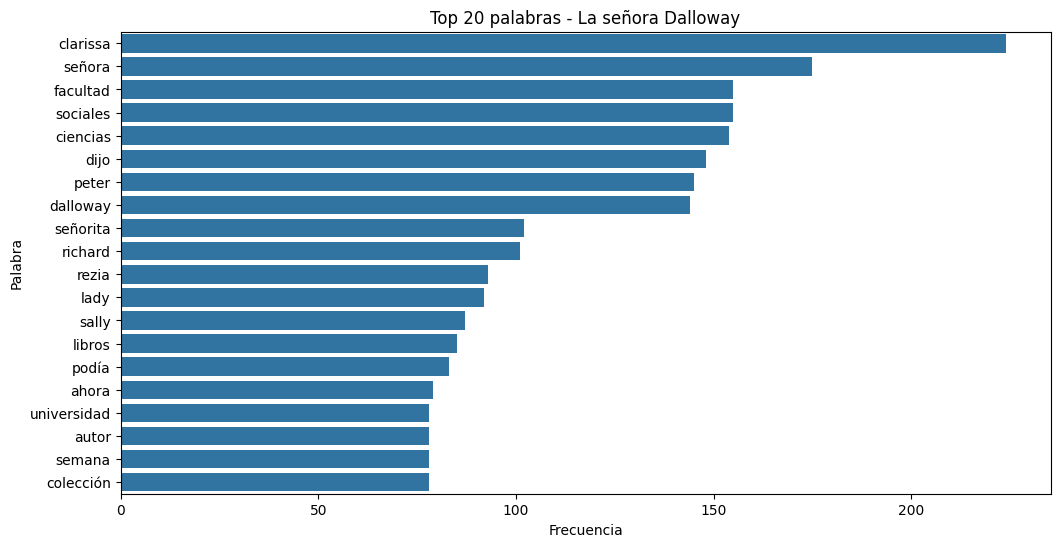

In [35]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top2,
    x="Frecuencia",
    y="Palabra"
)

plt.title(
    "Top 20 palabras - La señora Dalloway"
)

plt.show()

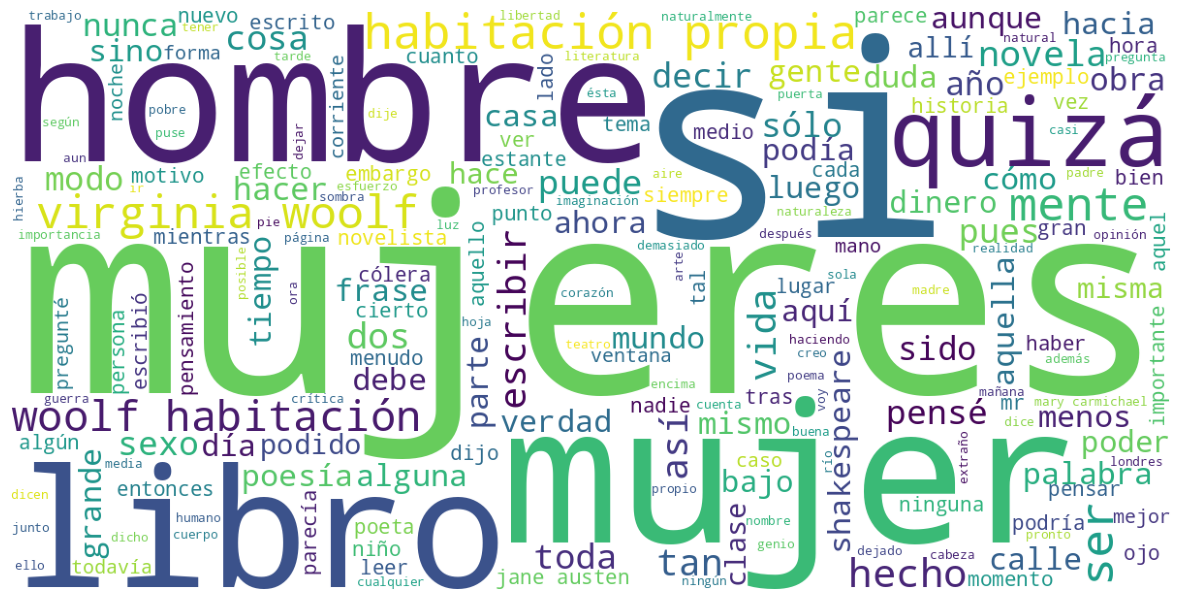

In [36]:
# Nube de palabras
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white'
)

wordcloud.generate(" ".join(tokens1))

plt.figure(figsize=(15,8))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

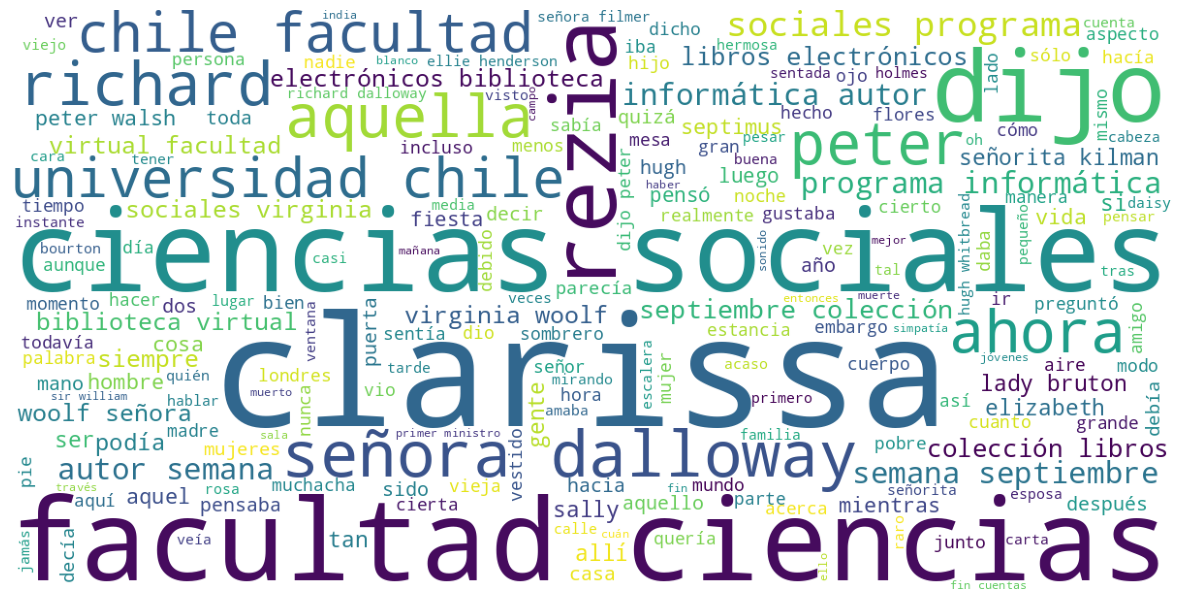

In [37]:
wordcloud.generate(" ".join(tokens2))

plt.figure(figsize=(15,8))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

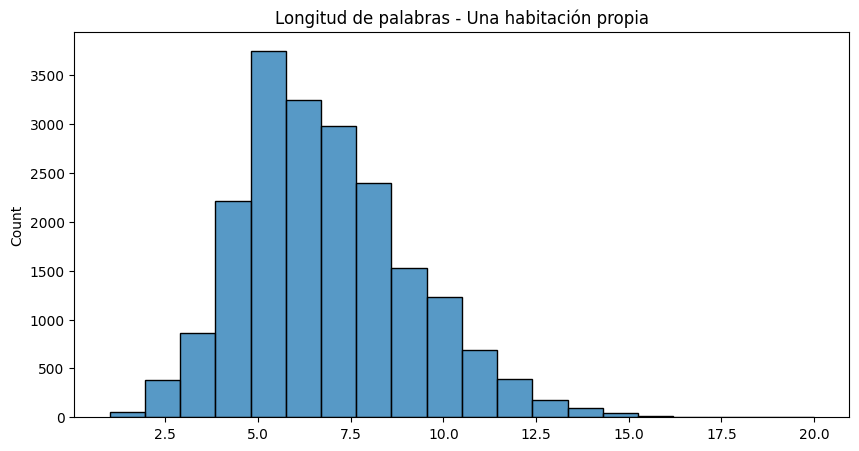

In [38]:
# Distribución de longitud de palabras
plt.figure(figsize=(10,5))

sns.histplot(
    [len(x) for x in tokens1],
    bins=20
)

plt.title(
    "Longitud de palabras - Una habitación propia"
)

plt.show()

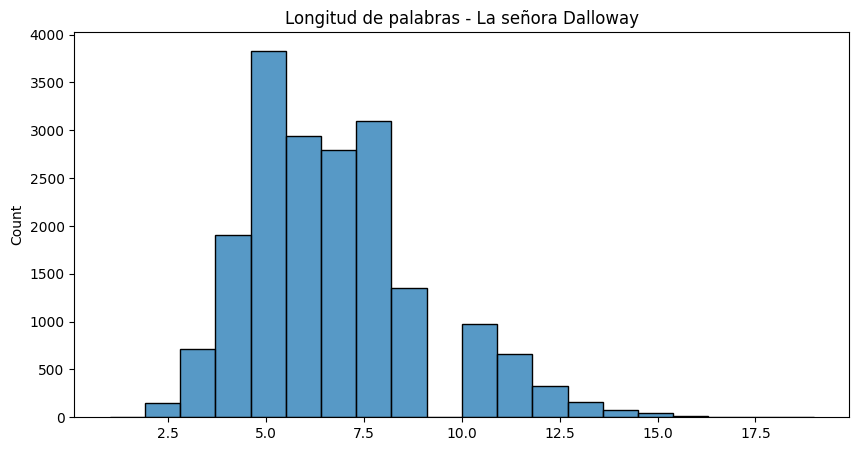

In [39]:
plt.figure(figsize=(10,5))

sns.histplot(
    [len(x) for x in tokens2],
    bins=20
)

plt.title(
    "Longitud de palabras - La señora Dalloway"
)

plt.show()

In [40]:
# Análisis de puntación
def signos_puntuacion(texto):

    signos = Counter(
        c for c in texto
        if c in ".,;:!?¿¡"
    )

    return signos

In [42]:
punt1 = signos_puntuacion(texto1)
punt2 = signos_puntuacion(texto2)

df_punt = pd.DataFrame(
    [punt1,punt2],
    index=[
        "Una habitación propia",
        "La señora Dalloway"
    ]
)

df_punt.fillna(0)

,:,.,",",¿,?,;,¡,!
Una habitación propia,103,1733,2895,156,155,342,20,22
La señora Dalloway,214,1704,3630,192,190,529,163,162


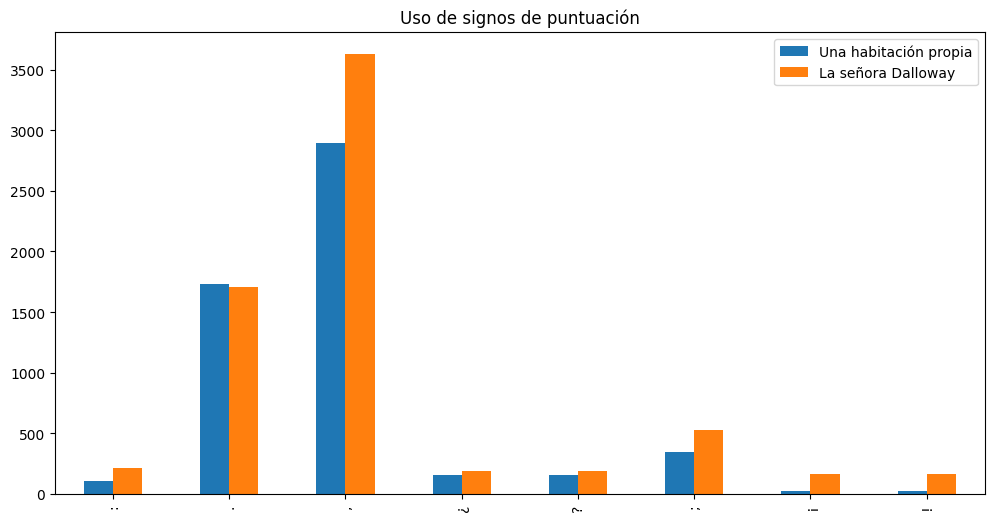

In [43]:
# Gráfica de puntuación
df_punt.T.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title(
    "Uso de signos de puntuación"
)

plt.show()

In [44]:
# Bigramas
bigramas1 = Counter(
    ngrams(tokens1,2)
)

bigramas2 = Counter(
    ngrams(tokens2,2)
)

pd.DataFrame(
    bigramas1.most_common(15),
    columns=["Bigrama","Frecuencia"]
)

,Bigrama,Frecuencia
0,"(habitación, propia)",91
1,"(virginia, woolf)",81
2,"(woolf, habitación)",81
3,"(jane, austen)",27
4,"(mary, carmichael)",20
5,"(quinientas, libras)",13
6,"(siglo, diecinueve)",13
7,"(mujeres, novela)",11
8,"(pensé, mirando)",11
9,"(libras, año)",10


In [45]:
#Trigramas
trigramas1 = Counter(
    ngrams(tokens1,3)
)

trigramas2 = Counter(
    ngrams(tokens2,3)
)

pd.DataFrame(
    trigramas1.most_common(15),
    columns=["Trigrama","Frecuencia"]
)

,Trigrama,Frecuencia
0,"(virginia, woolf, habitación)",81
1,"(woolf, habitación, propia)",81
2,"(my, heart, is)",9
3,"(quinientas, libras, año)",9
4,"(mr, oscar, browning)",8
5,"(heart, is, like)",7
6,"(habitación, propia, capítulo)",6
7,"(principios, siglo, diecinueve)",6
8,"(she, is, coming)",4
9,"(is, coming, my)",4


In [46]:
# Diversidad léxica
def diversidad(tokens):

    return len(set(tokens))/len(tokens)

In [47]:
div1 = diversidad(tokens1)
div2 = diversidad(tokens2)

print(
    "Diversidad Libro 1:",
    round(div1,3)
)

print(
    "Diversidad Libro 2:",
    round(div2,3)
)

Diversidad Libro 1: 0.361
Diversidad Libro 2: 0.303


In [48]:
# Comparación final
comparacion = pd.DataFrame({

    "Métrica":[
        "Palabras",
        "Vocabulario",
        "Longitud promedio",
        "Diversidad léxica"
    ],

    "Una habitación propia":[
        len(tokens1),
        len(set(tokens1)),
        round(np.mean([len(x) for x in tokens1]),2),
        round(div1,3)
    ],

    "La señora Dalloway":[
        len(tokens2),
        len(set(tokens2)),
        round(np.mean([len(x) for x in tokens2]),2),
        round(div2,3)
    ]
})

comparacion

,Métrica,Una habitación propia,La señora Dalloway
0,Palabras,20071.000,19060.000
1,Vocabulario,7239.000,5774.000
2,Longitud promedio,6.660,6.740
3,Diversidad léxica,0.361,0.303


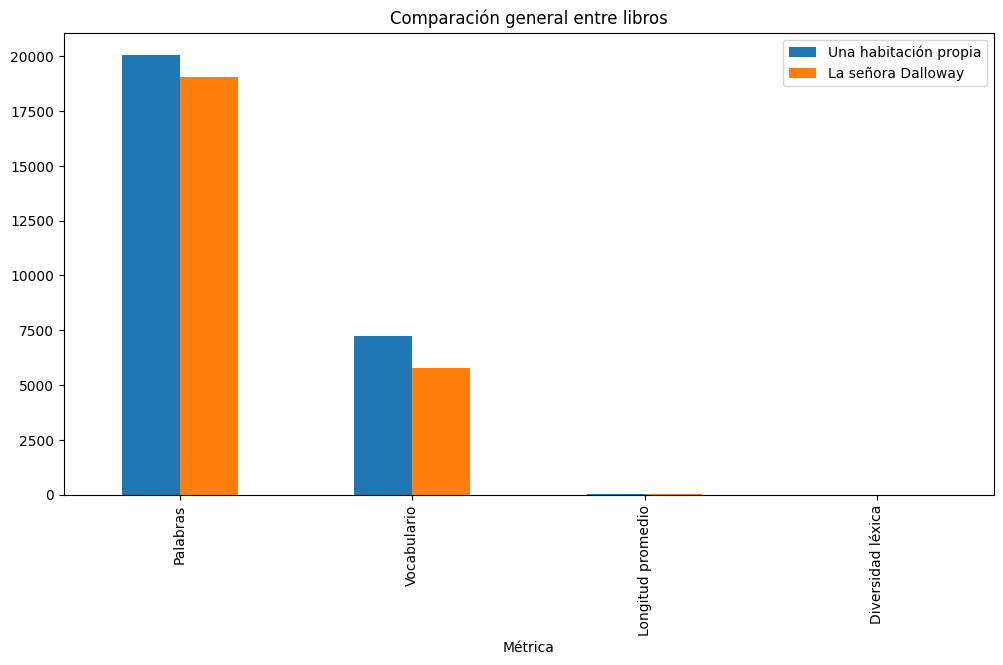

In [49]:
# Visualización comparativa
comparacion_graf = comparacion.set_index("Métrica")

comparacion_graf.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title(
    "Comparación general entre libros"
)

plt.show()